In [42]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import train_test_split

In [43]:
best_rf = joblib.load("../models/churn_model.pkl")

feature_names = joblib.load("../models/feature_names.pkl")

In [44]:
X_test = joblib.load("../models/X_test.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [45]:
pred_rf = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:,1]

In [46]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



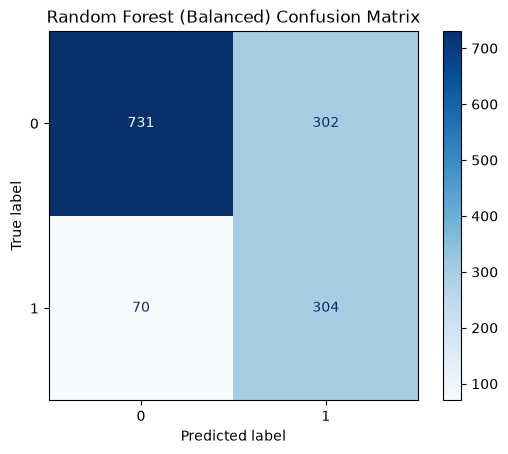

In [47]:
cm = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Random Forest (Balanced) Confusion Matrix")

plt.show()

In [48]:
roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.8397714977921115


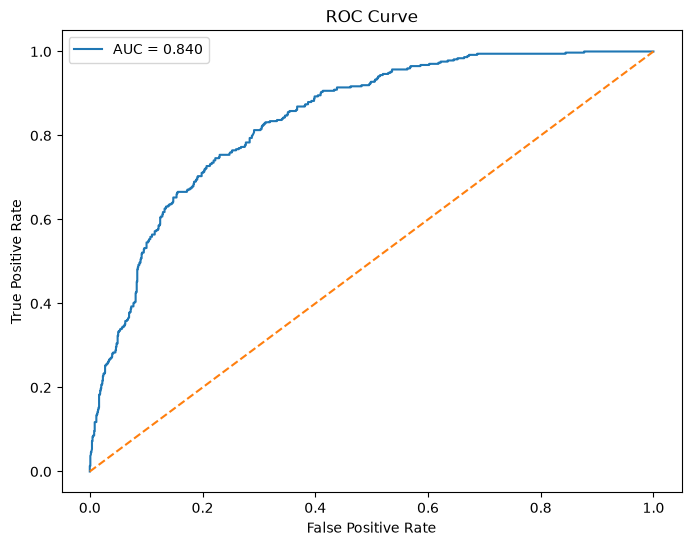

In [49]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc:.3f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [50]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,tenure,0.196355
19,Contract_Two year,0.151450
16,InternetService_Fiber optic,0.116870
15,TotalCharges,0.101024
14,MonthlyCharges,0.089736
21,PaymentMethod_Electronic check,0.077709
17,InternetService_No,0.062311
18,Contract_One year,0.053886
10,TechSupport,0.031086
7,OnlineSecurity,0.027611


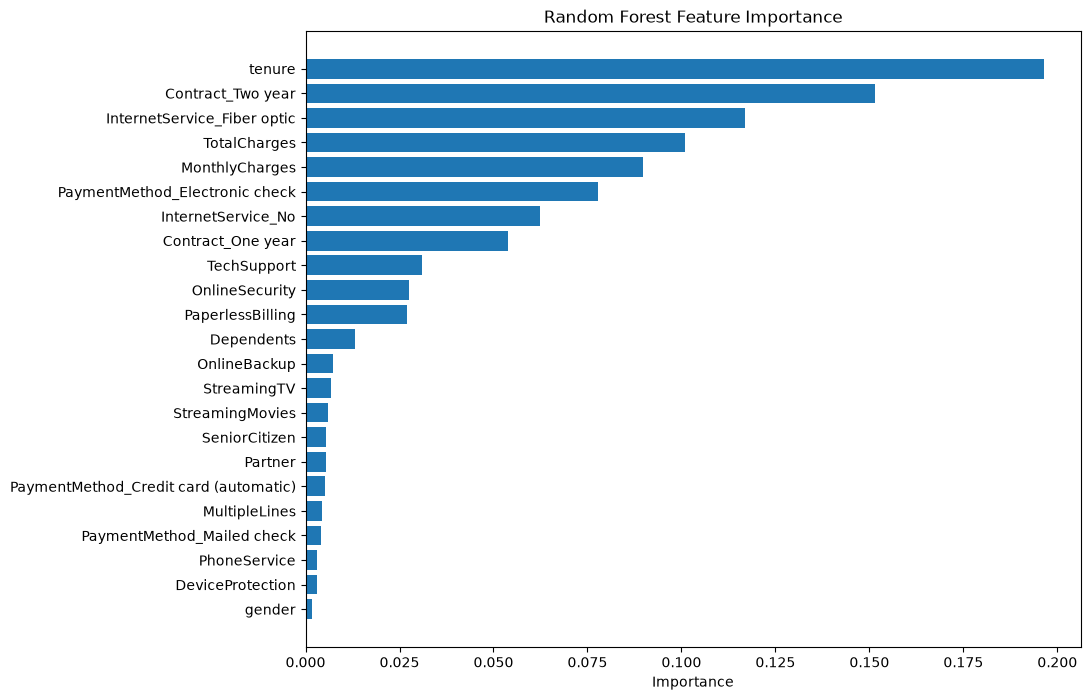

In [51]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.show()

### Business Insights
- Customers with shorter tenure are more likely to churn.
- Contract type strongly influences customer retention.
- Fiber optic customers exhibit higher churn.
- Monthly charges contribute to churn risk.
- Electronic check payment is associated with higher churn.

### Final Model Selection

- Five machine learning algorithms were evaluated.

- Although Gradient Boosting achieved the highest accuracy, the class-weighted Random Forest achieved the highest Recall and F1-score.

- Since customer churn prediction aims to identify customers at risk of leaving, maximizing Recall is more important than maximizing Accuracy.

- Therefore, the class-weighted Random Forest was selected as the final model.

### Conclusion

- An end-to-end customer churn prediction pipeline was developed.

- The final model achieved strong Recall while maintaining competitive overall performance.

- The trained model has been saved and is ready for deployment through a FastAPI backend and React frontend.